In [39]:
from qiskit import __version__
print(__version__)

2.4.1


# Importing Packages

In [40]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, Pauli, DensityMatrix, partial_trace
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_aer.library import SaveDensityMatrix, SaveStatevector, SetDensityMatrix
from qiskit import transpile 
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.circuit.library import HGate, UnitaryGate, IGate
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from scipy.optimize import curve_fit

# Graphing Settings

In [41]:
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.2,
    'figure.dpi': 150,
})

# Importing Data

In [42]:
data1 = np.load("depolarizing_error_rates.npz")
data2 = np.load("convergence_axis_error_rates.npz")

depol_input_error_rate = data1["input_error_rate_list"]
depol_output_error_rate = data1["output_error_rate"]
depol_intersection = data1["intersection"]
depol_ideal_output_error_rate = data1["ideal_output_error_rate"]
depol_cx_output_error_rate = data1["cx_output_error_rate"]
depol_h_output_error_rate = data1["h_output_error_rate"]
depol_meas_output_error_rate = data1["meas_output_error_rate"]
depol_meas_output_error_rate_unc = data1["meas_output_error_rate_unc"]
depol_all_output_error_rate = data1["all_output_error_rate"]
depol_all_output_error_rate_unc = data1["all_output_error_rate_unc"]
depol_hadamard_contributions = data1["hadamard_contributions"]
depol_cx_contributions = data1["cx_contributions"]
depol_measurement_contributions = data1["measurement_contributions"]
depol_one_qubit_gate_error_prob = data1["one_qubit_gate_error_prob"]


conv_input_error_rate = data2["input_error_rate_list"]
conv_output_error_rate = data2["output_error_rate"]
conv_intersection = data2["intersection"]
conv_ideal_output_error_rate = data2["ideal_output_error_rate"]
conv_cx_output_error_rate = data2["cx_output_error_rate"]
conv_h_output_error_rate = data2["h_output_error_rate"]
conv_meas_output_error_rate = data2["meas_output_error_rate"]
conv_meas_output_error_rate_unc = data2["meas_output_error_rate_unc"]
conv_all_output_error_rate = data2["all_output_error_rate"]
conv_all_output_error_rate_unc = data2["all_output_error_rate_unc"]
conv_hadamard_contributions = data2["hadamard_contributions"]
conv_cx_contributions = data2["cx_contributions"]
conv_measurement_contributions = data2["measurement_contributions"]
conv_one_qubit_gate_error_prob = data2["one_qubit_gate_error_prob"]

# Plots

Threshold plots

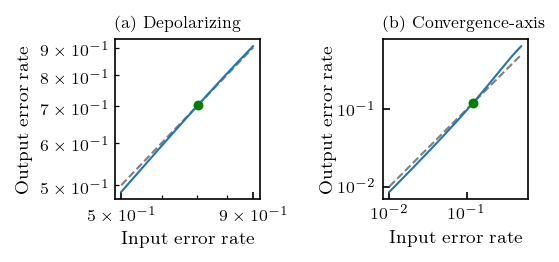

In [43]:
dep_x_intersect = depol_intersection
dep_y_intersect = depol_intersection

conv_x_intersect = conv_intersection
conv_y_intersect = conv_intersection

column_width = 3.4

fig, axes = plt.subplots(
    1, 2,
    figsize=(column_width, 1.75),
    sharex=False,
    sharey=False
)

# ── Plot 1: depolarizing noise ───────────────────────────
ax = axes[0]

ax.plot(
    depol_input_error_rate,
    depol_input_error_rate,
    color="gray",
    linestyle="--",
    linewidth=1.0
)

ax.plot(
    depol_input_error_rate,
    depol_output_error_rate,
    linewidth=1.0
)

ax.scatter(
    dep_x_intersect,
    dep_y_intersect,
    color="green",
    s=14,
    zorder=5
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Input error rate")
ax.set_ylabel("Output error rate")
ax.set_title(r"(a) Depolarizing", loc="left", fontsize=8)

# No top/right ticks
ax.tick_params(which='both', direction='in', top=False, right=False)

# Optional: choose compact x-axis ticks
ax.set_xticks([5e-1, 9e-1])
ax.set_xticklabels([r'$5\times10^{-1}$', r'$9\times10^{-1}$'])
ax.xaxis.set_minor_formatter(mticker.NullFormatter())


# ── Plot 2: convergence-axis noise ───────────────────────
ax = axes[1]

ax.plot(
    conv_input_error_rate,
    conv_input_error_rate,
    color="gray",
    linestyle="--",
    linewidth=1.0
)

ax.plot(
    conv_input_error_rate,
    conv_output_error_rate,
    linewidth=1.0
)

ax.scatter(
    conv_x_intersect,
    conv_y_intersect,
    color="green",
    s=14,
    zorder=5
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Input error rate")
ax.set_ylabel("Output error rate")
ax.set_title(r"(b) Convergence-axis", loc="left", fontsize=8)

# No top/right ticks
ax.tick_params(which='both', direction='in', top=False, right=False)

# Optional: choose compact x-axis ticks
ax.set_xticks([1e-2, 1e-1])
ax.set_xticklabels([r'$10^{-2}$', r'$10^{-1}$'])
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())
ax.yaxis.set_minor_locator(mticker.NullLocator())
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

# Reduce distance between plot 2's y-label and its axis
ax.yaxis.labelpad = 1


# Compact single-column APS-style spacing
fig.subplots_adjust(
    left=0.17,
    right=0.98,
    bottom=0.27,
    top=0.88,
    wspace=0.85
)

plt.show()

Error contributions plot: depolarizing

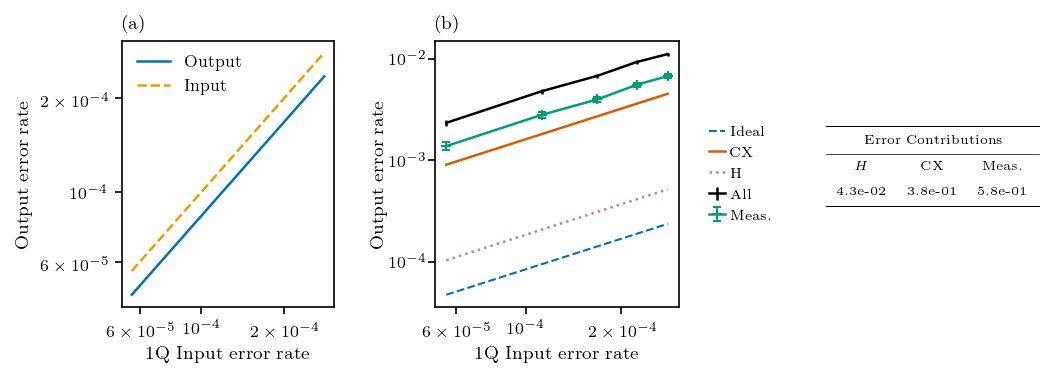

In [45]:
fig = plt.figure(figsize=(6.75, 2.65))

# Layout:
# plot 1 | spacer | plot 2 | legend | small spacer | table
gs = GridSpec(
    1, 6,
    figure=fig,
    width_ratios=[1.0, 0.45, 1.15, 0.55, 0.08, 1.05],
    wspace=0.02
)

ax1 = fig.add_subplot(gs[0])
ax_spacer_12 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
ax_leg = fig.add_subplot(gs[3])
ax_spacer_lt = fig.add_subplot(gs[4])
ax_table = fig.add_subplot(gs[5])

ax_spacer_12.axis('off')
ax_spacer_lt.axis('off')
ax_leg.axis('off')
ax_table.axis('off')

# ── Plot 1 ───────────────────────────────────────────────
ax1.plot(
    depol_one_qubit_gate_error_prob,
    depol_ideal_output_error_rate,
    color='#0072B2',
    linestyle='-',
    label='Output'
)

ax1.plot(
    depol_one_qubit_gate_error_prob,
    depol_one_qubit_gate_error_prob,
    color='#E69F00',
    linestyle='--',
    label='Input'
)

ax1.set_xscale('log')
ax1.set_yscale('log')

ax1.set_xticks([6e-5, 1e-4, 2e-4])
ax1.set_xticklabels([r'$6\times10^{-5}$', r'$10^{-4}$', r'$2\times10^{-4}$'])
ax1.set_yticks([6e-5, 1e-4, 2e-4])
ax1.set_yticklabels([r'$6\times10^{-5}$', r'$10^{-4}$', r'$2\times10^{-4}$'])
ax1.xaxis.set_minor_locator(mticker.NullLocator())
ax1.xaxis.set_minor_formatter(mticker.NullFormatter())
ax1.yaxis.set_minor_locator(mticker.NullLocator())
ax1.yaxis.set_minor_formatter(mticker.NullFormatter())

ax1.legend(frameon=False, loc='upper left')
ax1.set_ylabel('Output error rate')
ax1.set_xlabel('1Q Input error rate')
ax1.set_title('(a)', loc='left', fontsize=9)

# ── Plot 2 ───────────────────────────────────────────────
ax2.plot(
    depol_one_qubit_gate_error_prob,
    depol_ideal_output_error_rate,
    color='#0072B2',
    linestyle='--',
    linewidth=1.0,
    label='Ideal'
)

ax2.plot(
    depol_one_qubit_gate_error_prob,
    depol_cx_output_error_rate,
    color='#D55E00',
    linestyle='-',
    label='CX'
)

ax2.plot(
    depol_one_qubit_gate_error_prob,
    depol_h_output_error_rate,
    color='#CC79A7',
    linestyle=':',
    label='H'
)

ax2.errorbar(
    depol_one_qubit_gate_error_prob,
    depol_all_output_error_rate,
    yerr=depol_all_output_error_rate_unc,
    color='#000000',
    linestyle='-',
    label='All'
)

ax2.errorbar(
    depol_one_qubit_gate_error_prob,
    depol_meas_output_error_rate,
    yerr=depol_meas_output_error_rate_unc,
    fmt='+-',
    color='#009E73',
    capsize=2,
    markersize=5,
    elinewidth=0.8,
    label='Meas.'
)

ax2.set_xscale('log')
ax2.set_yscale('log')

ax2.set_xticks([6e-5, 1e-4, 2e-4])
ax2.set_xticklabels([r'$6\times10^{-5}$', r'$10^{-4}$', r'$2\times10^{-4}$'])
ax2.xaxis.set_minor_locator(mticker.NullLocator())
ax2.xaxis.set_minor_formatter(mticker.NullFormatter())
ax2.yaxis.set_minor_locator(mticker.NullLocator())
ax2.yaxis.set_minor_formatter(mticker.NullFormatter())

ax2.set_ylabel('Output error rate')
ax2.set_xlabel('1Q Input error rate')
ax2.set_title('(b)', loc='left', fontsize=9)

# Make plot 2 y-axis label/ticks compact
ax2.yaxis.labelpad = 1
ax2.tick_params(axis='y', which='both', pad=1)

# ── Legend right of Plot 2 ───────────────────────────────
handles, labels = ax2.get_legend_handles_labels()

ax_leg.legend(
    handles,
    labels,
    loc='center',
    frameon=False,
    fontsize=6.5,
    handlelength=1.2,
    handletextpad=0.35,
    labelspacing=0.65,
    borderaxespad=0.0
)

# ── Table right of legend ────────────────────────────────
ax_table.axis('off')
ax_table.set_xlim(0, 1)
ax_table.set_ylim(0, 1)

headers = [r'$H$', r'CX', r'Meas.']
values = [
    f'{depol_hadamard_contributions:.1e}',
    f'{depol_cx_contributions:.1e}',
    f'{depol_measurement_contributions:.1e}'
]

# Table position inside ax_table
x0 = 0.02
y0 = 0.38
width = 0.96
height = 0.30

col_w = width / 3

# Row y-positions
y_title = y0 + 0.82 * height
y_header = y0 + 0.50 * height
y_values = y0 + 0.18 * height

# Horizontal rule positions
y_top = y0 + height
y_mid = y0 + 0.65 * height
y_bottom = y0

# Font sizes
fs_title = 6.2
fs_body = 5.8

# Title
ax_table.text(
    x0 + width / 2,
    y_title,
    'Error Contributions',
    ha='center',
    va='center',
    fontsize=fs_title,
    fontweight='semibold',
    transform=ax_table.transAxes
)

# Horizontal rules only
ax_table.plot(
    [x0, x0 + width],
    [y_top, y_top],
    color='black',
    linewidth=0.5,
    transform=ax_table.transAxes,
    clip_on=False
)

ax_table.plot(
    [x0, x0 + width],
    [y_mid, y_mid],
    color='black',
    linewidth=0.35,
    transform=ax_table.transAxes,
    clip_on=False
)

ax_table.plot(
    [x0, x0 + width],
    [y_bottom, y_bottom],
    color='black',
    linewidth=0.5,
    transform=ax_table.transAxes,
    clip_on=False
)

# Headers and values
for j, header in enumerate(headers):
    x = x0 + (j + 0.5) * col_w

    ax_table.text(
        x,
        y_header,
        header,
        ha='center',
        va='center',
        fontsize=fs_body,
        transform=ax_table.transAxes
    )

    ax_table.text(
        x,
        y_values,
        values[j],
        ha='center',
        va='center',
        fontsize=fs_body,
        transform=ax_table.transAxes
    )

fig.subplots_adjust(
    left=0.08,
    right=0.99,
    bottom=0.23,
    top=0.90
)

plt.show()

Error contributions plot: convergence-axis

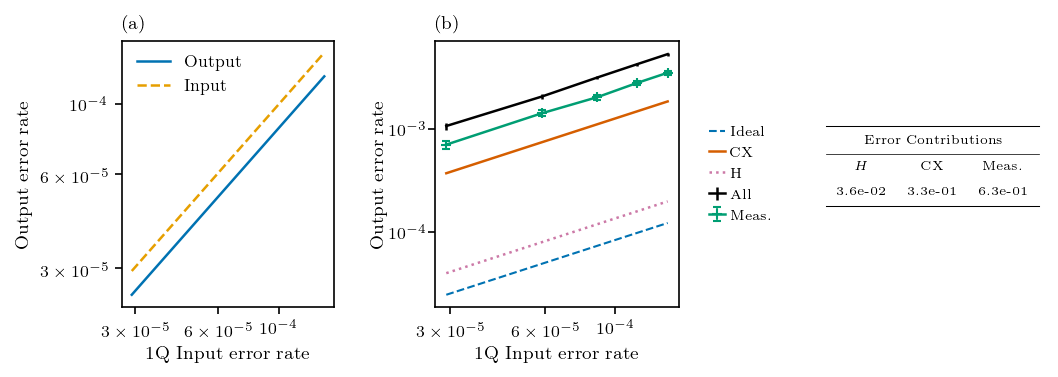

In [46]:
fig = plt.figure(figsize=(6.75, 2.65))

# Layout:
# plot 1 | spacer | plot 2 | legend | small spacer | table
gs = GridSpec(
    1, 6,
    figure=fig,
    width_ratios=[1.0, 0.45, 1.15, 0.55, 0.08, 1.05],
    wspace=0.02
)

ax1 = fig.add_subplot(gs[0])
ax_spacer_12 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
ax_leg = fig.add_subplot(gs[3])
ax_spacer_lt = fig.add_subplot(gs[4])
ax_table = fig.add_subplot(gs[5])

ax_spacer_12.axis('off')
ax_spacer_lt.axis('off')
ax_leg.axis('off')
ax_table.axis('off')

# ── Plot 1 ───────────────────────────────────────────────
ax1.plot(
    conv_one_qubit_gate_error_prob,
    conv_ideal_output_error_rate,
    color='#0072B2',
    linestyle='-',
    label='Output'
)

ax1.plot(
    conv_one_qubit_gate_error_prob,
    conv_one_qubit_gate_error_prob,
    color='#E69F00',
    linestyle='--',
    label='Input'
)

ax1.set_xscale('log')
ax1.set_yscale('log')

ax1.set_xticks([3e-5, 6e-5, 1e-4])
ax1.set_xticklabels([r'$3\times10^{-5}$', r'$6\times10^{-5}$', r'$10^{-4}$'])
ax1.set_yticks([3e-5, 6e-5, 1e-4])
ax1.set_yticklabels([r'$3\times10^{-5}$', r'$6\times10^{-5}$', r'$10^{-4}$'])
ax1.xaxis.set_minor_locator(mticker.NullLocator())
ax1.xaxis.set_minor_formatter(mticker.NullFormatter())
ax1.yaxis.set_minor_locator(mticker.NullLocator())
ax1.yaxis.set_minor_formatter(mticker.NullFormatter())

ax1.legend(frameon=False, loc='upper left')
ax1.set_ylabel('Output error rate')
ax1.set_xlabel('1Q Input error rate')
ax1.set_title('(a)', loc='left', fontsize=9)

# ── Plot 2 ───────────────────────────────────────────────
ax2.plot(
    conv_one_qubit_gate_error_prob,
    conv_ideal_output_error_rate,
    color='#0072B2',
    linestyle='--',
    linewidth=1.0,
    label='Ideal'
)

ax2.plot(
    conv_one_qubit_gate_error_prob,
    conv_cx_output_error_rate,
    color='#D55E00',
    linestyle='-',
    label='CX'
)

ax2.plot(
    conv_one_qubit_gate_error_prob,
    conv_h_output_error_rate,
    color='#CC79A7',
    linestyle=':',
    label='H'
)

ax2.errorbar(
    conv_one_qubit_gate_error_prob,
    conv_all_output_error_rate,
    yerr=conv_all_output_error_rate_unc,
    color='#000000',
    linestyle='-',
    label='All'
)

ax2.errorbar(
    conv_one_qubit_gate_error_prob,
    conv_meas_output_error_rate,
    yerr=conv_meas_output_error_rate_unc,
    fmt='+-',
    color='#009E73',
    capsize=2,
    markersize=5,
    elinewidth=0.8,
    label='Meas.'
)

ax2.set_xscale('log')
ax2.set_yscale('log')

ax2.set_xticks([3e-5, 6e-5, 1e-4])
ax2.set_xticklabels([r'$3\times10^{-5}$', r'$6\times10^{-5}$', r'$10^{-4}$'])
ax2.xaxis.set_minor_locator(mticker.NullLocator())
ax2.xaxis.set_minor_formatter(mticker.NullFormatter())
ax2.yaxis.set_minor_locator(mticker.NullLocator())
ax2.yaxis.set_minor_formatter(mticker.NullFormatter())

ax2.set_ylabel('Output error rate')
ax2.set_xlabel('1Q Input error rate')
ax2.set_title('(b)', loc='left', fontsize=9)

# Make plot 2 y-axis label/ticks compact
ax2.yaxis.labelpad = 1
ax2.tick_params(axis='y', which='both', pad=1)

# ── Legend right of Plot 2 ───────────────────────────────
handles, labels = ax2.get_legend_handles_labels()

ax_leg.legend(
    handles,
    labels,
    loc='center',
    frameon=False,
    fontsize=6.5,
    handlelength=1.2,
    handletextpad=0.35,
    labelspacing=0.65,
    borderaxespad=0.0
)

# ── Table right of legend ────────────────────────────────
ax_table.axis('off')
ax_table.set_xlim(0, 1)
ax_table.set_ylim(0, 1)

headers = [r'$H$', r'CX', r'Meas.']
values = [
    f'{conv_hadamard_contributions:.1e}',
    f'{conv_cx_contributions:.1e}',
    f'{conv_measurement_contributions:.1e}'
]

# Table position inside ax_table
x0 = 0.02
y0 = 0.38
width = 0.96
height = 0.30

col_w = width / 3

# Row y-positions
y_title = y0 + 0.82 * height
y_header = y0 + 0.50 * height
y_values = y0 + 0.18 * height

# Horizontal rule positions
y_top = y0 + height
y_mid = y0 + 0.65 * height
y_bottom = y0

# Font sizes
fs_title = 6.2
fs_body = 5.8

# Title
ax_table.text(
    x0 + width / 2,
    y_title,
    'Error Contributions',
    ha='center',
    va='center',
    fontsize=fs_title,
    fontweight='semibold',
    transform=ax_table.transAxes
)

# Horizontal rules only
ax_table.plot(
    [x0, x0 + width],
    [y_top, y_top],
    color='black',
    linewidth=0.5,
    transform=ax_table.transAxes,
    clip_on=False
)

ax_table.plot(
    [x0, x0 + width],
    [y_mid, y_mid],
    color='black',
    linewidth=0.35,
    transform=ax_table.transAxes,
    clip_on=False
)

ax_table.plot(
    [x0, x0 + width],
    [y_bottom, y_bottom],
    color='black',
    linewidth=0.5,
    transform=ax_table.transAxes,
    clip_on=False
)

# Headers and values
for j, header in enumerate(headers):
    x = x0 + (j + 0.5) * col_w

    ax_table.text(
        x,
        y_header,
        header,
        ha='center',
        va='center',
        fontsize=fs_body,
        transform=ax_table.transAxes
    )

    ax_table.text(
        x,
        y_values,
        values[j],
        ha='center',
        va='center',
        fontsize=fs_body,
        transform=ax_table.transAxes
    )

fig.subplots_adjust(
    left=0.08,
    right=0.99,
    bottom=0.23,
    top=0.90
)

plt.show()

Error contributions plots: together

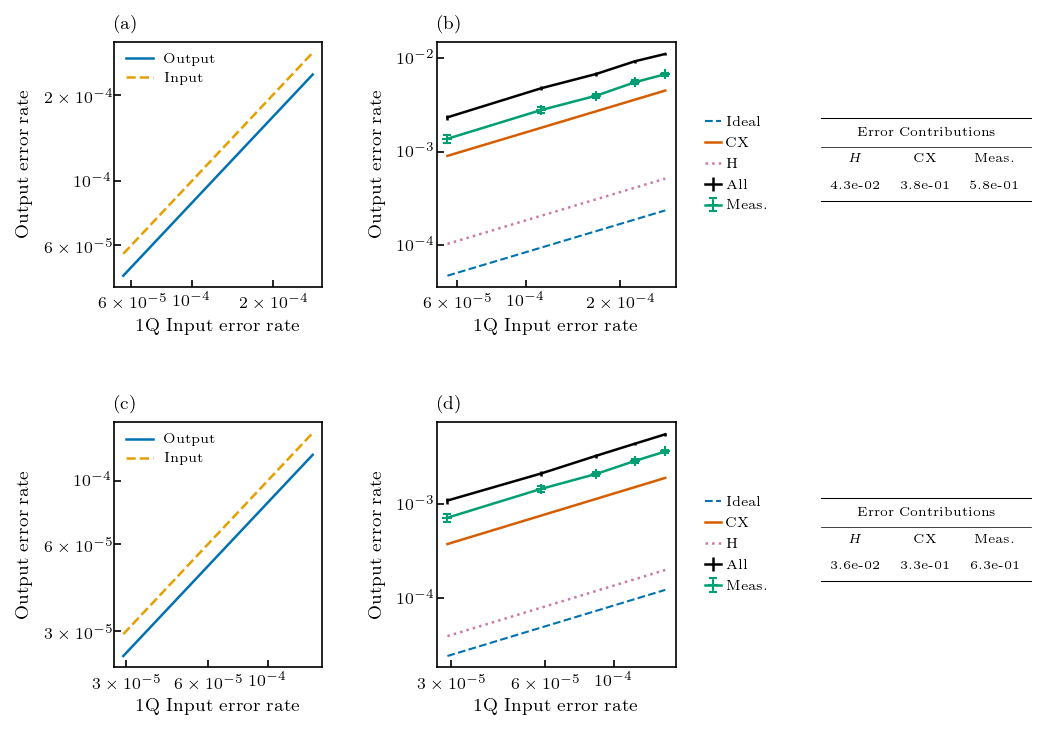

In [48]:
def format_log_axes(ax, xticks, xticklabels, yticks=None, yticklabels=None):
    ax.set_xscale('log')
    ax.set_yscale('log')

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)

    if yticks is not None:
        ax.set_yticks(yticks)
    else:
        ax.set_yticks(xticks)

    if yticklabels is not None:
        ax.set_yticklabels(yticklabels)
    else:
        ax.set_yticklabels(xticklabels)

    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())

    ax.tick_params(which='both', direction='in', top=False, right=False)
    ax.tick_params(axis='y', which='both', pad=1)
    ax.yaxis.labelpad = 1


def draw_error_contribution_table(ax_table, values):
    ax_table.axis('off')
    ax_table.set_xlim(0, 1)
    ax_table.set_ylim(0, 1)

    headers = [r'$H$', r'$\mathrm{CX}$', r'Meas.']

    x0 = 0.02
    y0 = 0.35
    width = 0.96
    height = 0.34
    col_w = width / 3

    y_title = y0 + 0.82 * height
    y_header = y0 + 0.50 * height
    y_values = y0 + 0.18 * height

    y_top = y0 + height
    y_mid = y0 + 0.65 * height
    y_bottom = y0

    fs_title = 6.2
    fs_body = 5.8

    ax_table.text(
        x0 + width / 2,
        y_title,
        'Error Contributions',
        ha='center',
        va='center',
        fontsize=fs_title,
        fontweight='semibold',
        transform=ax_table.transAxes
    )

    ax_table.plot(
        [x0, x0 + width],
        [y_top, y_top],
        color='black',
        linewidth=0.5,
        transform=ax_table.transAxes,
        clip_on=False
    )

    ax_table.plot(
        [x0, x0 + width],
        [y_mid, y_mid],
        color='black',
        linewidth=0.35,
        transform=ax_table.transAxes,
        clip_on=False
    )

    ax_table.plot(
        [x0, x0 + width],
        [y_bottom, y_bottom],
        color='black',
        linewidth=0.5,
        transform=ax_table.transAxes,
        clip_on=False
    )

    for j, header in enumerate(headers):
        x = x0 + (j + 0.5) * col_w

        ax_table.text(
            x,
            y_header,
            header,
            ha='center',
            va='center',
            fontsize=fs_body,
            transform=ax_table.transAxes
        )

        ax_table.text(
            x,
            y_values,
            values[j],
            ha='center',
            va='center',
            fontsize=fs_body,
            transform=ax_table.transAxes
        )


# ==========================================================
# Figure layout
# ==========================================================

fig = plt.figure(figsize=(6.75, 4.85))

gs = GridSpec(
    2, 6,
    figure=fig,
    width_ratios=[1.0, 0.52, 1.15, 0.55, 0.08, 1.05],
    height_ratios=[1.0, 1.0],
    wspace=0.02,
    hspace=0.55
)

# Top row: depolarizing noise
ax_a = fig.add_subplot(gs[0, 0])
ax_spacer_top_1 = fig.add_subplot(gs[0, 1])
ax_b = fig.add_subplot(gs[0, 2])
ax_leg_top = fig.add_subplot(gs[0, 3])
ax_spacer_top_2 = fig.add_subplot(gs[0, 4])
ax_table_top = fig.add_subplot(gs[0, 5])

# Bottom row: convergence-axis noise
ax_c = fig.add_subplot(gs[1, 0])
ax_spacer_bot_1 = fig.add_subplot(gs[1, 1])
ax_d = fig.add_subplot(gs[1, 2])
ax_leg_bot = fig.add_subplot(gs[1, 3])
ax_spacer_bot_2 = fig.add_subplot(gs[1, 4])
ax_table_bot = fig.add_subplot(gs[1, 5])

for ax in [
    ax_spacer_top_1, ax_spacer_top_2, ax_leg_top, ax_table_top,
    ax_spacer_bot_1, ax_spacer_bot_2, ax_leg_bot, ax_table_bot
]:
    ax.axis('off')


# ==========================================================
# Tick labels
# ==========================================================

depol_xticks = [6e-5, 1e-4, 2e-4]
depol_xticklabels = [
    r'$6\times10^{-5}$',
    r'$10^{-4}$',
    r'$2\times10^{-4}$'
]
depol_y1ticks = depol_xticks
depol_y1ticklabels = depol_xticklabels

depol_y2ticks = [1e-4, 1e-3, 1e-2]
depol_y2ticklabels = [
    r'$10^{-4}$',
    r'$10^{-3}$',
    r'$10^{-2}$'
]


conv_xticks = [3e-5, 6e-5, 1e-4]
conv_xticklabels = [
    r'$3\times10^{-5}$',
    r'$6\times10^{-5}$',
    r'$10^{-4}$'
]
conv_y1ticks = conv_xticks
conv_y1ticklabels = conv_xticklabels

conv_y2ticks = [1e-4, 1e-3]
conv_y2ticklabels = [
    r'$10^{-4}$',
    r'$10^{-3}$'
]

# ==========================================================
# Top row: depolarizing noise
# ==========================================================

# ── Panel (a) ─────────────────────────────────────────────
ax_a.plot(
    depol_one_qubit_gate_error_prob,
    depol_ideal_output_error_rate,
    color='#0072B2',
    linestyle='-',
    label='Output'
)

ax_a.plot(
    depol_one_qubit_gate_error_prob,
    depol_one_qubit_gate_error_prob,
    color='#E69F00',
    linestyle='--',
    label='Input'
)

format_log_axes(
    ax_a,
    depol_xticks,
    depol_xticklabels,
    depol_y1ticks,
    depol_y1ticklabels
)

ax_a.yaxis.labelpad = 6
ax_a.legend(frameon=False, loc='upper left', fontsize=6.5)
ax_a.set_ylabel('Output error rate')
ax_a.set_xlabel('1Q Input error rate')
ax_a.set_title('(a)', loc='left', fontsize=9)


# ── Panel (b) ─────────────────────────────────────────────
ax_b.plot(
    depol_one_qubit_gate_error_prob,
    depol_ideal_output_error_rate,
    color='#0072B2',
    linestyle='--',
    linewidth=1.0,
    label='Ideal'
)

ax_b.plot(
    depol_one_qubit_gate_error_prob,
    depol_cx_output_error_rate,
    color='#D55E00',
    linestyle='-',
    label='CX'
)

ax_b.plot(
    depol_one_qubit_gate_error_prob,
    depol_h_output_error_rate,
    color='#CC79A7',
    linestyle=':',
    label='H'
)

ax_b.errorbar(
    depol_one_qubit_gate_error_prob,
    depol_all_output_error_rate,
    yerr=depol_all_output_error_rate_unc,
    color='#000000',
    linestyle='-',
    label='All'
)

ax_b.errorbar(
    depol_one_qubit_gate_error_prob,
    depol_meas_output_error_rate,
    yerr=depol_meas_output_error_rate_unc,
    fmt='+-',
    color='#009E73',
    capsize=2,
    markersize=5,
    elinewidth=0.8,
    label='Meas.'
)

format_log_axes(
    ax_b,
    depol_xticks,
    depol_xticklabels,
    depol_y2ticks,
    depol_y2ticklabels
)

ax_b.yaxis.labelpad = 6
ax_b.set_ylabel('Output error rate')
ax_b.set_xlabel('1Q Input error rate')
ax_b.set_title('(b)', loc='left', fontsize=9)

handles_top, labels_top = ax_b.get_legend_handles_labels()

ax_leg_top.legend(
    handles_top,
    labels_top,
    loc='center',
    frameon=False,
    fontsize=6.5,
    handlelength=1.2,
    handletextpad=0.35,
    labelspacing=0.65,
    borderaxespad=0.0
)

depol_table_values = [
    f'{first_or_scalar(depol_hadamard_contributions):.1e}',
    f'{first_or_scalar(depol_cx_contributions):.1e}',
    f'{first_or_scalar(depol_measurement_contributions):.1e}'
]

draw_error_contribution_table(ax_table_top, depol_table_values)


# ==========================================================
# Bottom row: convergence-axis noise
# ==========================================================

# ── Panel (c) ─────────────────────────────────────────────
ax_c.plot(
    conv_one_qubit_gate_error_prob,
    conv_ideal_output_error_rate,
    color='#0072B2',
    linestyle='-',
    label='Output'
)

ax_c.plot(
    conv_one_qubit_gate_error_prob,
    conv_one_qubit_gate_error_prob,
    color='#E69F00',
    linestyle='--',
    label='Input'
)

format_log_axes(
    ax_c,
    conv_xticks,
    conv_xticklabels,
    conv_y1ticks,
    conv_y1ticklabels
)

ax_c.yaxis.labelpad = 6
ax_c.legend(frameon=False, loc='upper left', fontsize=6.5)
ax_c.set_ylabel('Output error rate')
ax_c.set_xlabel('1Q Input error rate')
ax_c.set_title('(c)', loc='left', fontsize=9)


# ── Panel (d) ─────────────────────────────────────────────
ax_d.plot(
    conv_one_qubit_gate_error_prob,
    conv_ideal_output_error_rate,
    color='#0072B2',
    linestyle='--',
    linewidth=1.0,
    label='Ideal'
)

ax_d.plot(
    conv_one_qubit_gate_error_prob,
    conv_cx_output_error_rate,
    color='#D55E00',
    linestyle='-',
    label='CX'
)

ax_d.plot(
    conv_one_qubit_gate_error_prob,
    conv_h_output_error_rate,
    color='#CC79A7',
    linestyle=':',
    label='H'
)

ax_d.errorbar(
    conv_one_qubit_gate_error_prob,
    conv_all_output_error_rate,
    yerr=conv_all_output_error_rate_unc,
    color='#000000',
    linestyle='-',
    label='All'
)

ax_d.errorbar(
    conv_one_qubit_gate_error_prob,
    conv_meas_output_error_rate,
    yerr=conv_meas_output_error_rate_unc,
    fmt='+-',
    color='#009E73',
    capsize=2,
    markersize=5,
    elinewidth=0.8,
    label='Meas.'
)

format_log_axes(
    ax_d,
    conv_xticks,
    conv_xticklabels,
    conv_y2ticks,
    conv_y2ticklabels
)

ax_d.yaxis.labelpad = 6
ax_d.set_ylabel('Output error rate')
ax_d.set_xlabel('1Q Input error rate')
ax_d.set_title('(d)', loc='left', fontsize=9)

handles_bot, labels_bot = ax_d.get_legend_handles_labels()

ax_leg_bot.legend(
    handles_bot,
    labels_bot,
    loc='center',
    frameon=False,
    fontsize=6.5,
    handlelength=1.2,
    handletextpad=0.35,
    labelspacing=0.65,
    borderaxespad=0.0
)

conv_table_values = [
    f'{first_or_scalar(conv_hadamard_contributions):.1e}',
    f'{first_or_scalar(conv_cx_contributions):.1e}',
    f'{first_or_scalar(conv_measurement_contributions):.1e}'
]

draw_error_contribution_table(ax_table_bot, conv_table_values)


# ==========================================================
# Final spacing and export
# ==========================================================

fig.subplots_adjust(
    left=0.08,
    right=0.99,
    bottom=0.10,
    top=0.96
)

plt.show()